## Trying to find methods to determine convergence

In [29]:
%load_ext memory_profiler
import os, gc
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
import pickle
import gzip
import matplotlib.pyplot as plt
import numpy as np
from memory_profiler import memory_usage
import sys
sys.path.append('/home/anas/Desktop/Simulations/Training_NLO/nonlinear_oscillator_network/Utils')

from NN_utils import *
from kneed import KneeLocator
import scipy
#from torchvision import datasets, transforms
#from torchsummary import summary
import time
from optimization_algorithms import * 

The memory_profiler extension is already loaded. To reload it, use:
  %reload_ext memory_profiler


In [2]:
def convergence_relative_improvement(loss_curve, threshold=1e-3, window=10):
    """
    Stop when relative improvement over 'window' steps is below 'threshold'.
    """
    for t in range(window, len(loss_curve)):
        rel_improvement = abs(loss_curve[t] - loss_curve[t-window]) / max(loss_curve[t-window], 1e-12)
        if rel_improvement < threshold:
            return t
    return len(loss_curve) - 1

def convergence_slope_loglog(loss_curve, threshold=1e-2, window=10):
    """
    Stop when slope on log-log curve over 'window' steps is below 'threshold'.
    """
    epochs = np.arange(1, len(loss_curve) + 1)  # avoid log(0)
    for t in range(window, len(loss_curve)):
        x = np.log(epochs[t-window:t+1])
        y = np.log(loss_curve[t-window:t+1] + 1e-12)
        slope, _ = np.polyfit(x, y, 1)  # linear fit
        if abs(slope) < threshold:
            return t
    return len(loss_curve) - 1

def convergence_relative_slope_loglog(loss_curve, fraction=0.01, window=10, eps=1e-12):
    """
    Converges when the local |slope| in log-log space falls below
    `fraction * max_abs_slope` (computed over all windows).
    """
    N = len(loss_curve)
    if N < max(3, window):
        return N - 1  # not enough data for a reliable slope

    epochs = np.arange(1, N + 1)  # avoid log(0)
    x_full = np.log(epochs)
    y_full = np.log(loss_curve + eps)

    # Compute local slopes via linear fit within each window (inclusive)
    slopes = []
    centers = []  # index to map each slope to an epoch (use right edge for consistency)
    for t in range(window - 1, N):
        x = x_full[t - (window - 1): t + 1]
        y = y_full[t - (window - 1): t + 1]
        slope, _ = np.polyfit(x, y, 1)
        slopes.append(slope)
        centers.append(t)  # right edge of the window

    slopes = np.array(slopes)
    centers = np.array(centers)

    max_abs_slope = np.max(np.abs(slopes))
    # If the curve is already flat (degenerate case)
    if max_abs_slope <= 0:
        return N - 1

    threshold = fraction * max_abs_slope

    # First epoch where local |slope| is small w.r.t. the max
    mask = np.abs(slopes) <= threshold
    if np.any(mask):
        return int(centers[np.argmax(mask)])  # first True
    else:
        return N - 1

def knee_point_loglog(loss_curve):
    """
    Find knee (elbow) of loss curve in log-log space using curvature.

    """
    epochs = np.arange(1, len(loss_curve) + 1)
    x = np.log(epochs)
    y = np.log(loss_curve + 1e-12)

    # first and second derivatives (finite differences)
    dy = np.gradient(y, x)
    d2y = np.gradient(dy, x)

    curvature = np.abs(d2y) / (1 + dy**2) ** 1.5
    knee_idx = np.argmax(curvature)
    return knee_idx

In [93]:
N_neurons_vec = [5, 10, 20 ,30, 50, 75, 100]

with open('paramscan_l2regularization_PNN_PEPG_MNIST.pkl', 'rb') as f:
    results1 = pickle.load(f)

with open('paramscan_l2regularization_PNN_PEPG_MNIST_run2.pkl', 'rb') as f:
    results2 = pickle.load(f)

with open('paramscan_l2regularization_PNN_PEPG_MNIST_run3.pkl', 'rb') as f:
    results3 = pickle.load(f)

dicts_list = [results1, results2,results3]  # list of runs

# Average them
avg_results_PEPG = []
for i in range(len(N_neurons_vec)):          # loop over neuron settings
    avg_dict = {}
    keys = dicts_list[0][i].keys()           # e.g. 'train_loss', 'test_loss'
    for key in keys:
        stacked = np.stack([d[i][key] for d in dicts_list])  # shape: (n_runs, vec_len)
        avg_dict[key] = stacked.mean(axis=0)
    avg_results_PEPG.append(avg_dict)

dict_keys(['train_loss', 'test_loss', 'test_acc', 'time', 'n_params'])

In [4]:
test_loss_mat = np.zeros((len(N_neurons_vec),len(avg_results_PEPG[0]['test_loss'])))
train_loss_mat = np.zeros((len(N_neurons_vec),len(avg_results_PEPG[0]['train_loss'])))

for k,D in enumerate(avg_results_PEPG):

    test_loss_mat[k,:] = D['test_loss']
    train_loss_mat[k,:] = D['train_loss']




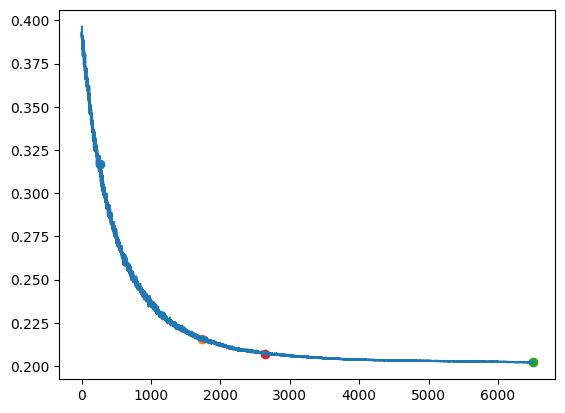

In [5]:
idx_curve =-1
idx_start = 500
idx_end = -1
loss_vec = test_loss_mat[idx_curve,idx_start:idx_end]
e_conv1 = convergence_relative_improvement(loss_vec, threshold=5e-3, window=50)
e_conv2 = convergence_slope_loglog(loss_vec, threshold=1e-2, window=50)
e_conv3 = convergence_relative_slope_loglog(loss_vec, fraction=1-2, window=50)
e_conv4 = knee_point_loglog(loss_vec)

plt.plot(loss_vec)
plt.scatter(e_conv1,loss_vec[e_conv1])
plt.scatter(e_conv2,loss_vec[e_conv2])
plt.scatter(e_conv3,loss_vec[e_conv3])
plt.scatter(e_conv4,loss_vec[e_conv4])


### Knee method below works quite well and is consistent
- it measures the distance from the normalized loss curve to a diagonal knee is reached when distance is max

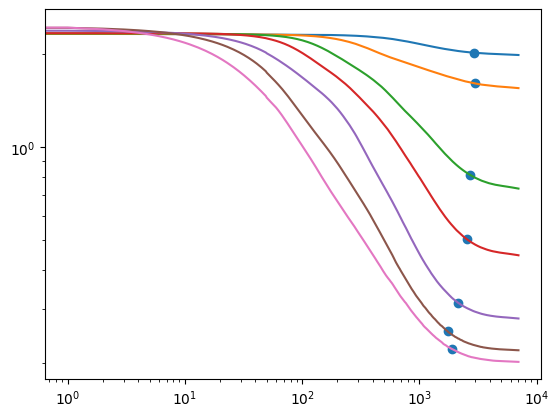

In [94]:

test_loss_mat = np.zeros((len(N_neurons_vec),len(avg_results_PEPG[0]['test_loss'])))
train_loss_mat = np.zeros((len(N_neurons_vec),len(avg_results_PEPG[0]['train_loss'])))

for k,D in enumerate(avg_results_PEPG):

    test_loss_mat[k,:] = D['test_loss']
    train_loss_mat[k,:] = D['train_loss']


test_loss_smooth = scipy.signal.savgol_filter(test_loss_mat,window_length=100,polyorder=3,axis=-1)
knee_idx_PEPG = []
idx_start = 500

for k in range(len(N_neurons_vec)):
    kneedle = KneeLocator(
        np.arange(idx_start,np.shape(test_loss_smooth)[-1]), test_loss_smooth[k,idx_start:7000+1],
        S=1.0,                     # sensitivity (larger -> fewer knees)
        curve="convex",            # try "concave" if your curve bends the other way
        direction="decreasing",    # loss goes down with epochs
        online=False
    )

    knee_idx_PEPG.append(int(kneedle.knee + idx_start)) 

loss_PEPG_conv = test_loss_smooth[np.arange(len(N_neurons_vec)),knee_idx_PEPG]

knee_idx_PEPG = np.array(knee_idx_PEPG)
plt.loglog(test_loss_smooth.T)
plt.scatter(knee_idx_PEPG,loss_PEPG_conv)

In [26]:
len(avg_results_PEPG[0]['test_loss'])

7000

In [7]:
print(knee_idx_PEPG)

[2898 2970 2720 2540 2141 1745 1891]


[4045, 8180, 16750, 25720, 44860, 71035, 99710]
slope 1.731253384084043
intercept -5.344750529260852


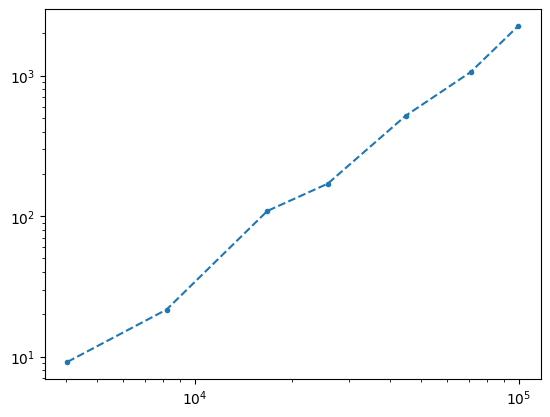

In [95]:
N_dim_vec = []
for k in range(len(avg_results_PEPG)):
    N_dim = int(avg_results_PEPG[k]['n_params'])
    N_dim_vec.append(N_dim)
#N_dim_vec = [4045, 8180, 16750, 25720, 44860, 71035, 99710]

print(N_dim_vec)
# peak memory data below was measured with the following dcript in the terminal command with or without scalene  : "scalene --html memory_profile_PEPG.py" only need to change N_dim in the .py script repeatedly
#added tracemalloc memory profiling because scalene does not monitor such a low memory usage per epoch


#PEPG_mem_perepoch = [4.824, 19.21,79.547,213.277 ,644.637,1616.281,3187.629] 
PEPG_mem_perepoch = np.array([6.324,14.541,80.003,133.988,486.040,1215.185 ,2392.625])/2/1000 # cost in MB more accurate, divide by 2 bcause float32 not 64

PEPG_cost_to_conv = PEPG_mem_perepoch * knee_idx_PEPG
plt.loglog(N_dim_vec,PEPG_cost_to_conv,'--.')

a_PEPG, b_PEPG = np.polyfit(np.log10(N_dim_vec), np.log10(PEPG_cost_to_conv), 1)  # linear fit
print(f'slope {a_PEPG}')
print(f'intercept {b_PEPG}')

In [ ]:
#print(cost_to_conv)
print(N_dim_vec)

NameError: name 'cost_to_conv' is not defined

In [10]:
N_neurons_vec = [5, 10, 20 ,30, 50, 75, 100,150,250]

with gzip.open('paramscan_PNN_SPSA_MNIST_run1.pkl.gz', 'rb') as f:
    results_SPSA1 = pickle.load(f)

with gzip.open('paramscan_PNN_SPSA_MNIST_run2.pkl.gz', 'rb') as f:
    results_SPSA2 = pickle.load(f)

with gzip.open('paramscan_PNN_SPSA_MNIST_run3.pkl.gz', 'rb') as f:
    results_SPSA3 = pickle.load(f)

dicts_list = [results_SPSA1, results_SPSA2,results_SPSA3]  # list of runs

# Average them
avg_results_SPSA = []
for i in range(len(N_neurons_vec)):          # loop over neuron settings
    avg_dict = {}
    keys = dicts_list[0][i].keys()           # e.g. 'train_loss', 'test_loss'
    for key in keys:
        stacked = np.stack([d[i][key] for d in dicts_list])  # shape: (n_runs, vec_len)
        avg_dict[key] = stacked.mean(axis=0)
    avg_results_SPSA.append(avg_dict)

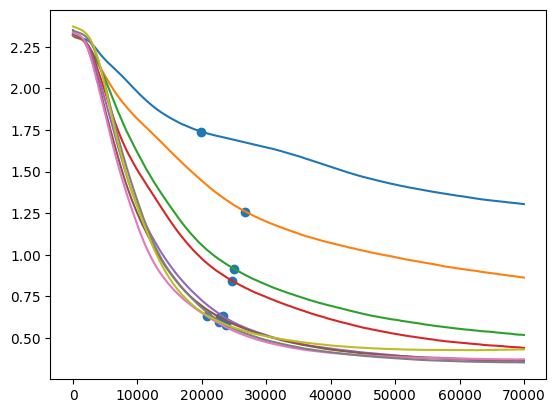

In [11]:

N_neurons_vec = [5, 10, 20 ,30, 50, 75, 100,150,250]


test_loss_mat = np.zeros((len(N_neurons_vec),len(avg_results_SPSA[0]['test_loss'])))
train_loss_mat = np.zeros((len(N_neurons_vec),len(avg_results_SPSA[0]['train_loss'])))

for k,D in enumerate(avg_results_SPSA):

    test_loss_mat[k,:] = D['test_loss']
    train_loss_mat[k,:] = D['train_loss']



idx_start = 3000
test_loss_smooth = scipy.signal.savgol_filter(test_loss_mat,window_length=100,polyorder=3,axis=-1)
knee_idx_SPSA = []
for k in range(len(N_neurons_vec)):
    kneedle = KneeLocator(
        np.arange(idx_start,np.shape(test_loss_smooth)[-1]), test_loss_smooth[k,idx_start:len(avg_results_SPSA[0]['test_loss'])+1],
        S=1.0,                     # sensitivity (larger -> fewer knees)
        curve="convex",            # try "concave" if your curve bends the other way
        direction="decreasing",    # loss goes down with epochs
        online=False
    )

    knee_idx_SPSA.append(int(kneedle.knee + idx_start)) 

knee_idx_SPSA = np.array(knee_idx_SPSA)
loss_SPSA_conv = test_loss_smooth[np.arange(len(N_neurons_vec)),knee_idx_SPSA]
plt.plot(test_loss_smooth.T)
plt.scatter(knee_idx_SPSA,loss_SPSA_conv)

In [13]:
len(avg_results_SPSA)

9

[4045, 8180, 16750, 25720, 44860, 71035, 99710, 164560, 324260]
slope 0.851671893329662
intercept 0.851671893329662


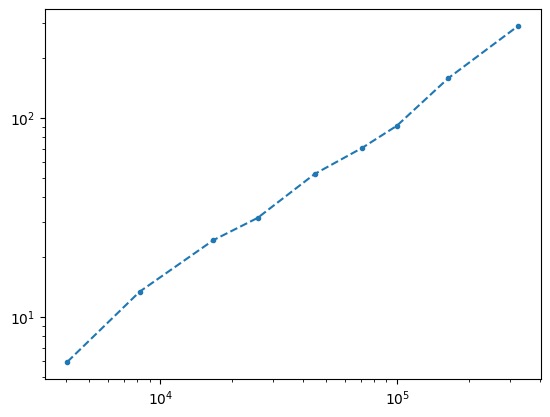

In [15]:
N_dim_vec_SPSA = []
for k in range(len(avg_results_SPSA)):
    N_dim = int(avg_results_SPSA[k]['n_params'])
    N_dim_vec_SPSA.append(N_dim)
#N_dim_vec = [4045, 8180, 16750, 25720, 44860, 71035, 99710]

print(N_dim_vec_SPSA)
# peak memory data below was measured with the following terminal command  : "scalene --html memory_profile_SPSA.py" only need to change N_dim in the .py script repeatedly
#added tracemalloc memory profiling because scalene does not monitor such a low memory usage per epoch

#SPSA_mem_perepoch = [1.102, 1.554,2.559,3.516,5.373,8.092,11.039] # cost in MB 
#SPSA_mem_perepoch = [3.314, 3.875,5.022,5.906,8.131,10.953,14.787] # cost in MB 
SPSA_mem_perepoch = np.array([0.596, 0.999,1.942,2.535,4.489,6.197,8.794,13.341,25.559 ])/2/1000 # cost in MB more accurate

SPSA_cost_to_conv = SPSA_mem_perepoch * knee_idx_SPSA
plt.loglog(N_dim_vec_SPSA,SPSA_cost_to_conv,'--.')

a_SPSA, b_SPSA = np.polyfit(np.log10(N_dim_vec_SPSA), np.log10(SPSA_cost_to_conv), 1)  # linear fit
print(f'slope {a_SPSA}')
print(f'intercept {a_SPSA}')

In [23]:
knee_idx_SPSA[0] = 28000

In [57]:
N_neurons_vec = [5, 10, 20 ,30, 50, 75, 100,150,250]

with gzip.open('paramscan_PNN_BP_MNIST_run1.pkl.gz', 'rb') as f:
    results_BP1 = pickle.load(f)

with gzip.open('paramscan_PNN_BP_MNIST_run2.pkl.gz', 'rb') as f:
    results_BP2 = pickle.load(f)

with gzip.open('paramscan_PNN_BP_MNIST_run3.pkl.gz', 'rb') as f:
    results_BP3 = pickle.load(f)

dicts_list = [results_BP1, results_BP2,results_BP3]  # list of runs

# Average them
avg_results_BP = []
for i in range(len(N_neurons_vec)):          # loop over neuron settings
    avg_dict = {}
    keys = dicts_list[0][i].keys()           # e.g. 'train_loss', 'test_loss'
    for key in keys:
        stacked = np.stack([d[i][key] for d in dicts_list])  # shape: (n_runs, vec_len)
        avg_dict[key] = stacked.mean(axis=0)
    avg_results_BP.append(avg_dict)

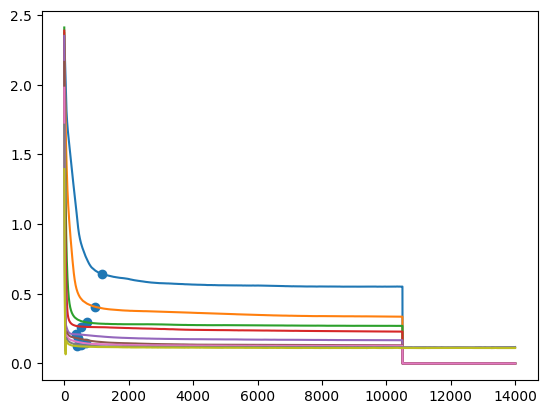

In [84]:

N_neurons_vec = [5, 10, 20 ,30, 50, 75, 100,150,250]


test_loss_mat = np.zeros((len(N_neurons_vec),len(avg_results_BP[-1]['test_loss'])))
train_loss_mat = np.zeros((len(N_neurons_vec),len(avg_results_BP[-1]['train_loss'])))
test_loss_smooth_mat = np.zeros((len(N_neurons_vec),len(avg_results_BP[-1]['test_loss'])))
idx_start = 100
knee_idx_BP = []

for k,D in enumerate(avg_results_BP):

    test_loss_mat[k,:len( D['test_loss'])] = D['test_loss']
    train_loss_mat[k,:len(D['train_loss'])] = D['train_loss']

    test_loss_smooth = scipy.signal.savgol_filter(test_loss_mat[k,:len( D['test_loss'])],window_length=100,polyorder=3,axis=-1)
    test_loss_smooth_mat[k,:len(test_loss_smooth)] = test_loss_smooth

    kneedle = KneeLocator(
        np.arange(idx_start,np.shape(test_loss_smooth)[-1]), test_loss_smooth[idx_start:],
        S=1.0,                     # sensitivity (larger -> fewer knees)
        curve="convex",            # try "concave" if your curve bends the other way
        direction="decreasing",    # loss goes down with epochs
        online=False
    )

    knee_idx_BP.append(int(kneedle.knee + idx_start)) 

knee_idx_BP = np.array(knee_idx_BP)
loss_BP_conv = test_loss_smooth_mat[np.arange(len(N_neurons_vec)),knee_idx_BP]
plt.plot(test_loss_smooth_mat.T)
plt.scatter(knee_idx_BP,loss_BP_conv)

In [85]:
knee_idx_BP

array([1161,  953,  715,  516,  372,  413,  660,  513,  389])

[4045, 8180, 16750, 25720, 44860, 71035, 99710, 164560, 324260]
slope 0.7775078204782266
intercept -4.909007050902446


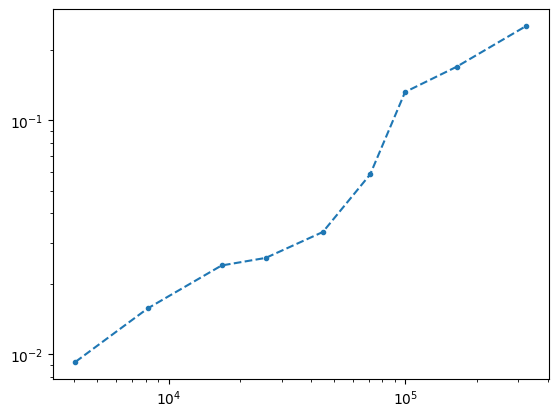

In [90]:
N_dim_vec_BP = []
for k in range(len(avg_results_BP)):
    N_dim = int(avg_results_BP[k]['n_params'])
    N_dim_vec_BP.append(N_dim)
#N_dim_vec = [4045, 8180, 16750, 25720, 44860, 71035, 99710]

print(N_dim_vec_BP)
# peak memory data below was measured with the following terminal command  : "scalene --html memory_profile_SPSA.py" only need to change N_dim in the .py script repeatedly
#added tracemalloc memory profiling because scalene does not monitor such a low memory usage per epoch
BP_mem_perepoch = np.array([0.016,0.033,0.067, 0.1, 0.179, 0.284, 0.399,0.658 ,1.297])/2/1000

#BP_mem_perepoch = [0.193,0.193, 0.45,1.049 ,3.3 ,6.2,6.618] # cost in MB more accurate

BP_cost_to_conv = BP_mem_perepoch * knee_idx_BP
plt.loglog(N_dim_vec_BP,BP_cost_to_conv,'--.')

a_BP, b_BP = np.polyfit(np.log10(N_dim_vec_BP), np.log10(BP_cost_to_conv), 1)  # linear fit
print(f'slope {a_BP}')
print(f'intercept {b_BP}')

### Performance vs number params

BP loss-fit:    slope=-0.379, intercept=1.106
PEPG loss-fit:  slope=-0.755, intercept=3.075
SPSA loss-fit:  slope=-0.411, intercept=1.715


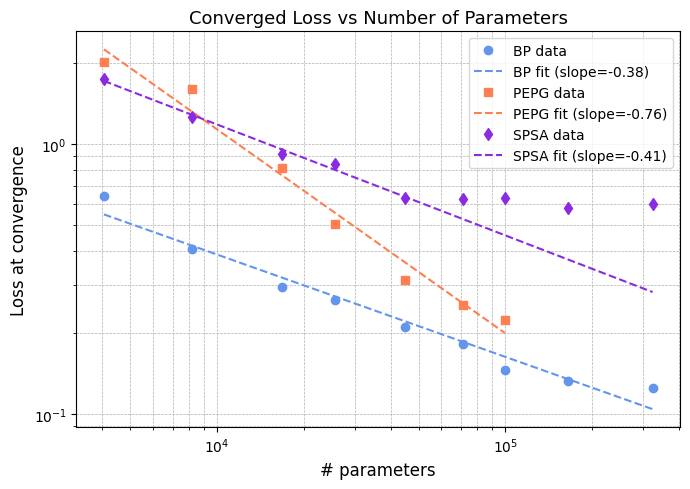

In [96]:
# ----- power-law fits (log-log) -----
a_BP_l,   b_BP_l   = np.polyfit(np.log10(N_dim_vec_BP), np.log10(loss_BP_conv),   1)
a_PEPG_l, b_PEPG_l = np.polyfit(np.log10(N_dim_vec), np.log10(loss_PEPG_conv), 1)
a_SPSA_l, b_SPSA_l = np.polyfit(np.log10(N_dim_vec_SPSA[:-4]), np.log10(loss_SPSA_conv[:-4]), 1)

print(f"BP loss-fit:    slope={a_BP_l:.3f}, intercept={b_BP_l:.3f}")
print(f"PEPG loss-fit:  slope={a_PEPG_l:.3f}, intercept={b_PEPG_l:.3f}")
print(f"SPSA loss-fit:  slope={a_SPSA_l:.3f}, intercept={b_SPSA_l:.3f}")

# Predicted fits in original scale
fit_BP    = 10**(a_BP_l   * np.log10(N_dim_vec_BP) + b_BP_l)
fit_PEPG  = 10**(a_PEPG_l * np.log10(N_dim_vec) + b_PEPG_l)
fit_SPSA  = 10**(a_SPSA_l * np.log10(N_dim_vec_SPSA) + b_SPSA_l)

# ----- plotting -----
plt.figure(figsize=(7,5))

# BP — cornflower blue
plt.loglog(N_dim_vec_BP, loss_BP_conv, 'o', color='cornflowerblue', label='BP data')
plt.loglog(N_dim_vec_BP, fit_BP, '--',  color='cornflowerblue', label=f'BP fit (slope={a_BP_l:.2f})')

# PEPG — coral
plt.loglog(N_dim_vec, loss_PEPG_conv, 's', color='coral', label='PEPG data')
plt.loglog(N_dim_vec, fit_PEPG, '--',  color='coral', label=f'PEPG fit (slope={a_PEPG_l:.2f})')

# SPSA — blueviolet
plt.loglog(N_dim_vec_SPSA, loss_SPSA_conv, 'd', color='blueviolet', label='SPSA data')
plt.loglog(N_dim_vec_SPSA, fit_SPSA, '--',  color='blueviolet', label=f'SPSA fit (slope={a_SPSA_l:.2f})')

plt.xlabel(r'# parameters', fontsize=12)
plt.ylabel('Loss at convergence', fontsize=12)
plt.title('Converged Loss vs Number of Parameters', fontsize=13)
plt.legend()
plt.grid(True, which="both", ls="--", lw=0.5)
plt.tight_layout()
plt.show()

### Cost to convergence plot

BP:    slope=0.778, intercept=-4.909
PEPG:  slope=1.731, intercept=-5.345
SPSA:  slope=0.852, intercept=-2.253


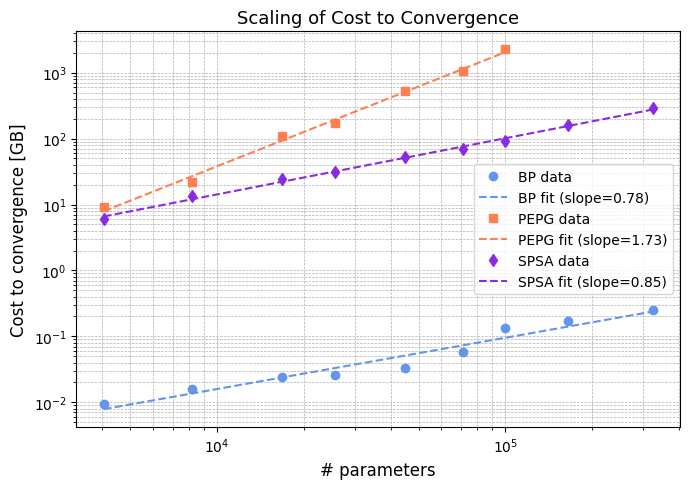

In [97]:
# Fit lines (log-log)
a_BP, b_BP = np.polyfit(np.log10(N_dim_vec_BP), np.log10(BP_cost_to_conv), 1)
a_PEPG, b_PEPG = np.polyfit(np.log10(N_dim_vec), np.log10(PEPG_cost_to_conv), 1)
a_SPSA, b_SPSA = np.polyfit(np.log10(N_dim_vec_SPSA), np.log10(SPSA_cost_to_conv), 1)

# Print slopes and intercepts
print(f"BP:    slope={a_BP:.3f}, intercept={b_BP:.3f}")
print(f"PEPG:  slope={a_PEPG:.3f}, intercept={b_PEPG:.3f}")
print(f"SPSA:  slope={a_SPSA:.3f}, intercept={b_SPSA:.3f}")

# Plot data and fits
plt.figure(figsize=(7,5))

# BP - black
plt.loglog(N_dim_vec_BP, BP_cost_to_conv, 'o', color='cornflowerblue', label='BP data')
plt.loglog(N_dim_vec_BP, 10**(a_BP*np.log10(N_dim_vec_BP) + b_BP), '--', color='cornflowerblue', label=f'BP fit (slope={a_BP:.2f})')

# PEPG - orange
plt.loglog(N_dim_vec, PEPG_cost_to_conv, 's', color='coral', label='PEPG data')
plt.loglog(N_dim_vec, 10**(a_PEPG*np.log10(N_dim_vec) + b_PEPG), '--', color='coral', label=f'PEPG fit (slope={a_PEPG:.2f})')

# SPSA - purple
plt.loglog(N_dim_vec_SPSA, SPSA_cost_to_conv, 'd', color='blueviolet', label='SPSA data')
plt.loglog(N_dim_vec_SPSA, 10**(a_SPSA*np.log10(N_dim_vec_SPSA) + b_SPSA), '--', color='blueviolet', label=f'SPSA fit (slope={a_SPSA:.2f})')

# Labels and style
plt.xlabel(r'# parameters', fontsize=12)
plt.ylabel('Cost to convergence [GB]', fontsize=12)
plt.title('Scaling of Cost to Convergence', fontsize=13)
plt.legend()
plt.grid(True, which="both", ls="--", lw=0.5)
plt.tight_layout()
plt.show()

### Loss vs cost to convergence

BP:    slope=-0.557, intercept=-1.411
PEPG:  slope=-0.435, intercept=0.740
SPSA:  slope=-0.465, intercept=0.610


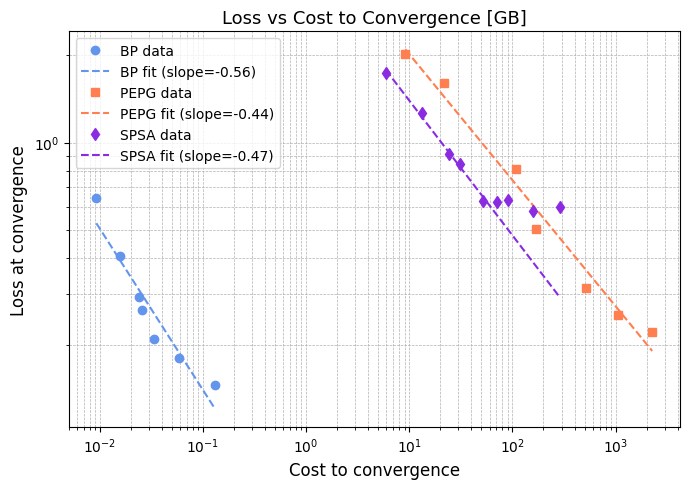

In [24]:
# Fit lines (log-log)
a_BP, b_BP = np.polyfit(np.log10(BP_cost_to_conv),   np.log10(loss_BP_conv),   1)
a_PEPG, b_PEPG = np.polyfit(np.log10(PEPG_cost_to_conv), np.log10(loss_PEPG_conv), 1)
a_SPSA, b_SPSA = np.polyfit(np.log10(SPSA_cost_to_conv[:-4]), np.log10(loss_SPSA_conv[:-4]), 1)

# Print slopes and intercepts
print(f"BP:    slope={a_BP:.3f}, intercept={b_BP:.3f}")
print(f"PEPG:  slope={a_PEPG:.3f}, intercept={b_PEPG:.3f}")
print(f"SPSA:  slope={a_SPSA:.3f}, intercept={b_SPSA:.3f}")

# Plot data and fits
plt.figure(figsize=(7,5))

# BP — cornflower blue
plt.loglog(BP_cost_to_conv, loss_BP_conv, 'o', color='cornflowerblue', label='BP data')
plt.loglog(BP_cost_to_conv, 10**(a_BP*np.log10(BP_cost_to_conv) + b_BP), '--', color='cornflowerblue', label=f'BP fit (slope={a_BP:.2f})')

# PEPG — coral
plt.loglog(PEPG_cost_to_conv, loss_PEPG_conv, 's', color='coral', label='PEPG data')
plt.loglog(PEPG_cost_to_conv, 10**(a_PEPG*np.log10(PEPG_cost_to_conv) + b_PEPG), '--', color='coral', label=f'PEPG fit (slope={a_PEPG:.2f})')

# SPSA — blueviolet
plt.loglog(SPSA_cost_to_conv, loss_SPSA_conv, 'd', color='blueviolet', label='SPSA data')
plt.loglog(SPSA_cost_to_conv, 10**(a_SPSA*np.log10(SPSA_cost_to_conv) + b_SPSA), '--', color='blueviolet', label=f'SPSA fit (slope={a_SPSA:.2f})')

# Labels and styling
plt.xlabel('Cost to convergence', fontsize=12)
plt.ylabel('Loss at convergence', fontsize=12)
plt.title('Loss vs Cost to Convergence [GB]', fontsize=13)
plt.legend()
plt.grid(True, which="both", ls="--", lw=0.5)
plt.tight_layout()
plt.show()#

BP loss-fit:    slope=-0.464, intercept=0.102
PEPG loss-fit:  slope=-0.807, intercept=0.926
SPSA loss-fit:  slope=-0.356, intercept=0.457


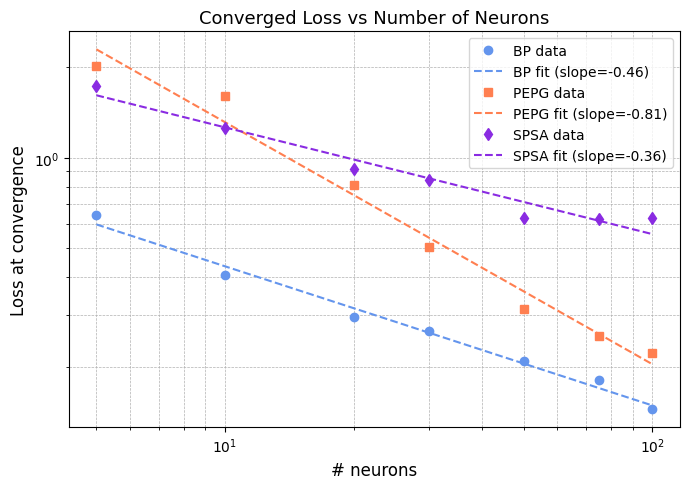

In [81]:
# ----- power-law fits (log-log) -----
a_BP_l,   b_BP_l   = np.polyfit(np.log10(N_neurons_vec), np.log10(loss_BP_conv),   1)
a_PEPG_l, b_PEPG_l = np.polyfit(np.log10(N_neurons_vec), np.log10(loss_PEPG_conv), 1)
a_SPSA_l, b_SPSA_l = np.polyfit(np.log10(N_neurons_vec), np.log10(loss_SPSA_conv), 1)

print(f"BP loss-fit:    slope={a_BP_l:.3f}, intercept={b_BP_l:.3f}")
print(f"PEPG loss-fit:  slope={a_PEPG_l:.3f}, intercept={b_PEPG_l:.3f}")
print(f"SPSA loss-fit:  slope={a_SPSA_l:.3f}, intercept={b_SPSA_l:.3f}")

# Predicted fits in original scale
fit_BP    = 10**(a_BP_l   * np.log10(N_neurons_vec) + b_BP_l)
fit_PEPG  = 10**(a_PEPG_l * np.log10(N_neurons_vec) + b_PEPG_l)
fit_SPSA  = 10**(a_SPSA_l * np.log10(N_neurons_vec) + b_SPSA_l)

# ----- plotting -----
plt.figure(figsize=(7,5))

# BP — cornflower blue
plt.loglog(N_neurons_vec, loss_BP_conv, 'o', color='cornflowerblue', label='BP data')
plt.loglog(N_neurons_vec, fit_BP, '--',  color='cornflowerblue', label=f'BP fit (slope={a_BP_l:.2f})')

# PEPG — coral
plt.loglog(N_neurons_vec, loss_PEPG_conv, 's', color='coral', label='PEPG data')
plt.loglog(N_neurons_vec, fit_PEPG, '--',  color='coral', label=f'PEPG fit (slope={a_PEPG_l:.2f})')

# SPSA — blueviolet
plt.loglog(N_neurons_vec, loss_SPSA_conv, 'd', color='blueviolet', label='SPSA data')
plt.loglog(N_neurons_vec, fit_SPSA, '--',  color='blueviolet', label=f'SPSA fit (slope={a_SPSA_l:.2f})')

plt.xlabel(r'# neurons', fontsize=12)
plt.ylabel('Loss at convergence', fontsize=12)
plt.title('Converged Loss vs Number of Neurons', fontsize=13)
plt.legend()
plt.grid(True, which="both", ls="--", lw=0.5)
plt.tight_layout()
plt.show()


In [28]:
google = 1
uol = 2 

np.random.randint(3)

1